# Validation: Health Estimation Quality

The health domain uses the most complex estimation method: GP-level QOF
prevalence rates are disaggregated to LSOAs using patient registration
weights. This notebook validates the quality of that estimation:

1. **National prevalence comparison:** do weighted-up LSOA estimates
   match the raw national QOF averages?
2. **Prevalence rate distributions:** are the LSOA-level estimates in
   plausible ranges?
3. **Interpolation impact:** how many LSOAs required temporal
   interpolation, and does it introduce artefacts?
4. **Disease correlation structure:** diseases known to co-occur
   (e.g. CHD, HYP, DM) should be positively correlated

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if repo_root.name in ("validation", "nbs", "pts"):
    repo_root = repo_root.parent
while not (repo_root / "config").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

lsoa_dir = repo_root / "store" / "outputs" / "default" / "lsoa" / "health"
eng_dir = repo_root / "store" / "outputs" / "default" / "england" / "health"
pipeline_dir = repo_root / "store" / "pipeline" / "default" / "health"

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

## 1. National prevalence: ADI estimate vs raw QOF

The England-level aggregated rate should closely match what we'd get
by simply dividing total disease register by total list population
in the raw QOF data. Discrepancies indicate issues in the GP-weighting
or crosswalk steps.

In [2]:
# Load raw QOF data to compute national prevalence directly
qof_dir = repo_root / "store" / "inputs" / "qof"

# Load pipeline (pre-crosswalk) and output (post-crosswalk) for comparison
eng_files = sorted(eng_dir.glob("health_*.csv"))

national_comparison = []
for f in eng_files:
    qof_year = f.stem.replace("health_", "")
    eng = pd.read_csv(f)

    # Also load LSOA-level to compute weighted-up national rate
    lsoa_path = lsoa_dir / f.name
    if not lsoa_path.exists():
        continue
    lsoa = pd.read_csv(lsoa_path)

    rate_cols = [c for c in eng.columns if c.endswith("_afflicted_rate")]
    for col in rate_cols:
        disease = col.replace("_afflicted_rate", "")
        count_col = f"{disease}_afflicted"
        if count_col not in lsoa.columns:
            continue

        # England-level rate from aggregate node
        eng_rate = eng[col].iloc[0]

        # Recomputed from LSOA counts
        lsoa_count_sum = lsoa[count_col].sum()
        lsoa_pop_sum = lsoa["pop"].sum()
        recomputed_rate = lsoa_count_sum / lsoa_pop_sum if lsoa_pop_sum > 0 else np.nan

        national_comparison.append({
            "year": qof_year,
            "disease": disease,
            "eng_rate": eng_rate,
            "recomputed_from_lsoa": recomputed_rate,
            "diff": abs(eng_rate - recomputed_rate) if not np.isnan(recomputed_rate) else np.nan,
        })

comp_df = pd.DataFrame(national_comparison)

# Show summary: are England rates consistent with LSOA rollup?
max_diff = comp_df["diff"].max()
print(f"England rate vs LSOA recomputed rate — max absolute diff: {max_diff:.2e}")
if max_diff < 1e-10:
    print("PASSED: England rates are exactly consistent with LSOA rollup.")
else:
    print("\nLargest discrepancies:")
    print(comp_df.nlargest(10, "diff").to_string(index=False))

England rate vs LSOA recomputed rate — max absolute diff: 9.97e-17
PASSED: England rates are exactly consistent with LSOA rollup.


## 2. Prevalence rate distributions

For a recent year, plot the distribution of each disease prevalence
rate across LSOAs. Extreme outliers or bimodal distributions may
indicate estimation artefacts.

In [3]:
latest_file = sorted(lsoa_dir.glob("health_*.csv"))[-1]
df = pd.read_csv(latest_file)
rate_cols = sorted([c for c in df.columns if c.endswith("_afflicted_rate")])
diseases = [c.replace("_afflicted_rate", "") for c in rate_cols]

# Summary statistics
stats = []
for col, disease in zip(rate_cols, diseases):
    vals = df[col].dropna()
    stats.append({
        "disease": disease,
        "n_valid": len(vals),
        "mean": vals.mean(),
        "median": vals.median(),
        "std": vals.std(),
        "min": vals.min(),
        "max": vals.max(),
        "p1": vals.quantile(0.01),
        "p99": vals.quantile(0.99),
        "n_nan": df[col].isna().sum(),
        "n_zero": (df[col] == 0).sum(),
    })

stats_df = pd.DataFrame(stats)
print(f"Health prevalence rate statistics — {latest_file.name}:")
print(stats_df.to_string(index=False))

Health prevalence rate statistics — health_2024_25.csv:
disease  n_valid     mean   median      std      min      max       p1      p99  n_nan  n_zero
     AF    33749 0.023386 0.023816 0.008943 0.000789 0.060500 0.005491 0.045541      0       0
    AST    33749 0.063186 0.064726 0.012063 0.001874 0.108456 0.033442 0.087394      0       0
    CAN    33749 0.039388 0.039607 0.012396 0.001286 0.086031 0.012996 0.069517      0       0
    CHD    33749 0.030764 0.030630 0.009303 0.000993 0.074749 0.010823 0.054110      0       0
    CKD    33749 0.038483 0.036954 0.013813 0.001157 0.110131 0.012702 0.076708      0       0
   COPD    33749 0.019628 0.018657 0.007998 0.000567 0.068896 0.005735 0.040532      0       0
  CVDPP    33749 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000      0   33749
    DEM    33749 0.008118 0.007963 0.003193 0.000258 0.055833 0.002032 0.016822      0       0
    DEP    33749 0.117071 0.115031 0.029373 0.003348 0.256407 0.054587 0.190535      0   

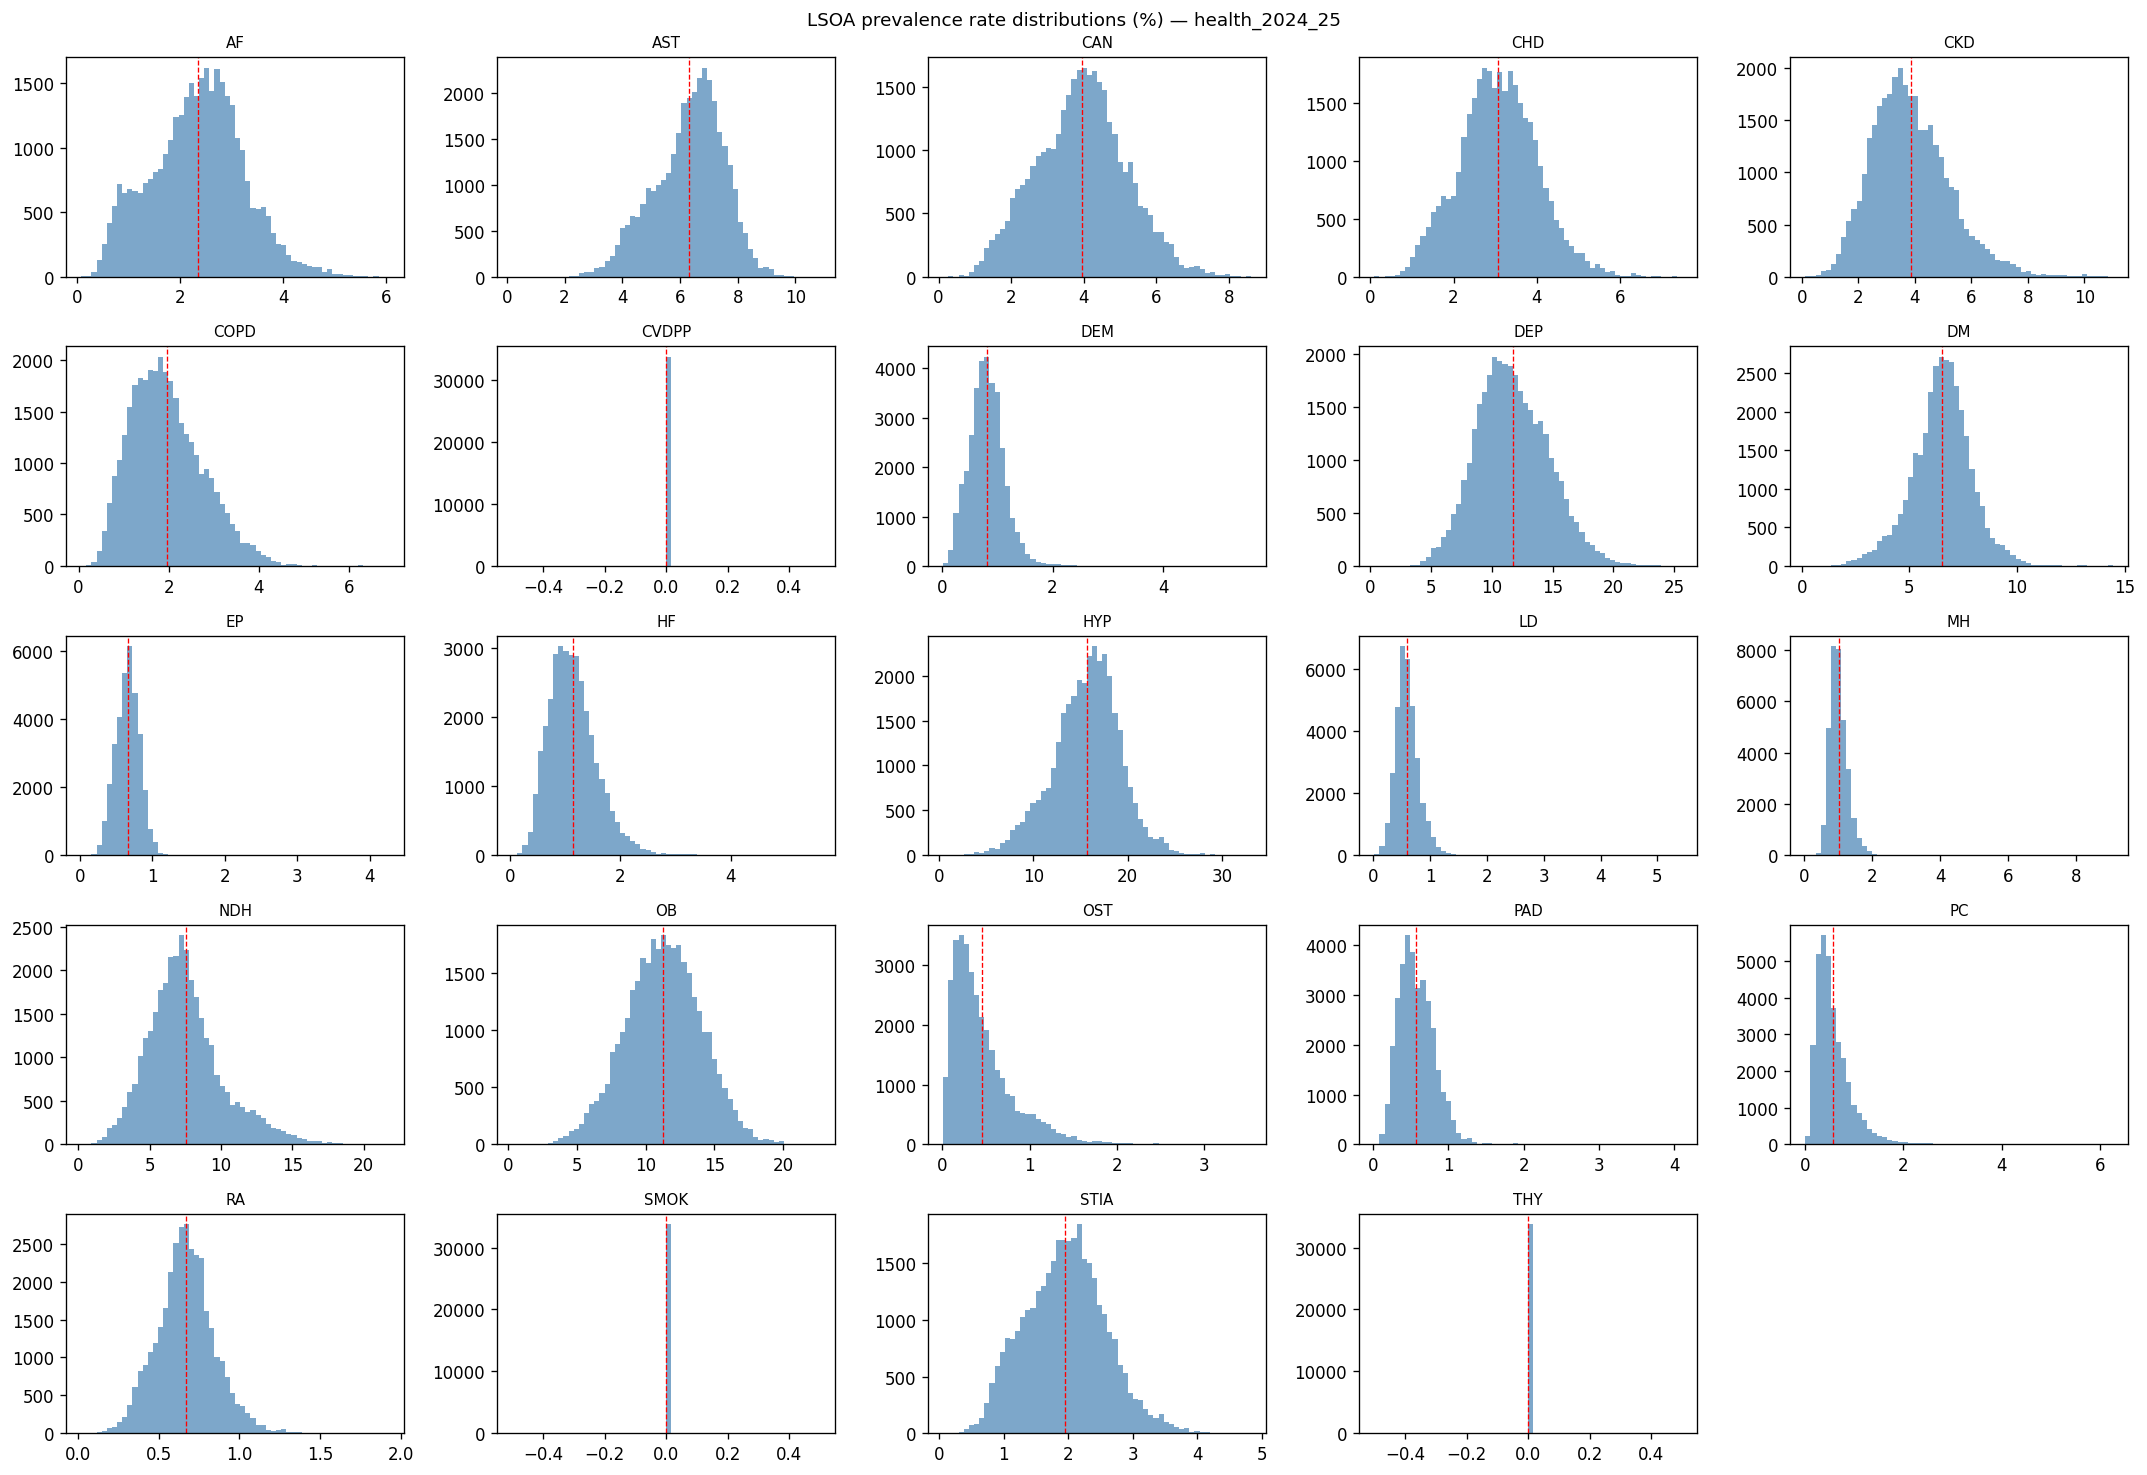

In [4]:
# Histogram grid of all disease prevalence rates
n_diseases = len(diseases)
n_cols = 5
n_rows = (n_diseases + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 2.5))
axes = axes.flatten()

for i, (col, disease) in enumerate(zip(rate_cols, diseases)):
    vals = df[col].dropna() * 100
    axes[i].hist(vals, bins=60, color="steelblue", alpha=0.7, edgecolor="none")
    axes[i].set_title(disease, fontsize=9)
    axes[i].axvline(vals.mean(), color="red", linewidth=0.8, linestyle="--")

for i in range(len(diseases), len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f"LSOA prevalence rate distributions (%) — {latest_file.stem}", fontsize=11)
fig.tight_layout()
plt.show()

## 3. Interpolation impact analysis

Compare pipeline (pre-crosswalk, LSOA 2011) outputs across years to
detect which diseases and years show evidence of interpolation (smooth
constant slopes in otherwise variable data).

We look at the number of LSOAs with identical values across consecutive
years — a sign of linear interpolation filling gaps.

In [5]:
pipeline_files = sorted(pipeline_dir.glob("health_*.csv"))

interp_indicators = []
for i in range(len(pipeline_files) - 1):
    year_a = pipeline_files[i].stem.replace("health_", "")
    year_b = pipeline_files[i + 1].stem.replace("health_", "")
    df_a = pd.read_csv(pipeline_files[i])
    df_b = pd.read_csv(pipeline_files[i + 1])

    merged = df_a.merge(df_b, on="LSOA11CD", suffixes=("_a", "_b"))
    rate_cols = [c for c in df_a.columns if c.endswith("_prevalence_rate")]

    for col in rate_cols:
        disease = col.replace("_prevalence_rate", "")
        col_a = f"{col}_a"
        col_b = f"{col}_b"
        if col_a not in merged.columns or col_b not in merged.columns:
            continue

        both_valid = merged[[col_a, col_b]].dropna()
        if len(both_valid) == 0:
            continue

        # Count NaNs in each year
        nan_a = df_a[col].isna().sum()
        nan_b = df_b[col].isna().sum()

        interp_indicators.append({
            "period": f"{year_a}→{year_b}",
            "disease": disease,
            "n_valid_both": len(both_valid),
            "nan_year_a": nan_a,
            "nan_year_b": nan_b,
        })

interp_df = pd.DataFrame(interp_indicators)

# Show diseases with high NaN counts (these needed interpolation)
high_nan = interp_df[interp_df[["nan_year_a", "nan_year_b"]].max(axis=1) > 100]
if len(high_nan) > 0:
    print("Disease-year pairs with >100 NaN LSOAs (candidates for interpolation):")
    print(high_nan.to_string(index=False))
else:
    print("No disease-year pairs with >100 NaN LSOAs.")

# Summary: NaN counts per disease across all years
nan_by_disease = interp_df.groupby("disease")[["nan_year_a", "nan_year_b"]].max()
nan_by_disease["max_nan"] = nan_by_disease.max(axis=1)
nan_by_disease = nan_by_disease.sort_values("max_nan", ascending=False)
print("\nMax NaN count per disease across all years:")
print(nan_by_disease.head(15).to_string())

No disease-year pairs with >100 NaN LSOAs.

Max NaN count per disease across all years:
         nan_year_a  nan_year_b  max_nan
disease                                 
AF                0           0        0
AST               0           0        0
RA                0           0        0
PC                0           0        0
PAD               0           0        0
OST               0           0        0
OB                0           0        0
NDH               0           0        0
MH                0           0        0
LD                0           0        0
HYP               0           0        0
HF                0           0        0
EP                0           0        0
DM                0           0        0
DEP               0           0        0


## 4. Disease correlation structure

Diseases that share risk factors should be positively correlated at
the LSOA level. This serves as a sanity check that the GP-weighting
method produces sensible spatial patterns.

Expected positive correlations:
- CHD, HYP, DM, CKD (cardiovascular/metabolic cluster)
- COPD, SMOK (respiratory/smoking)
- DEM, HF (age-related)

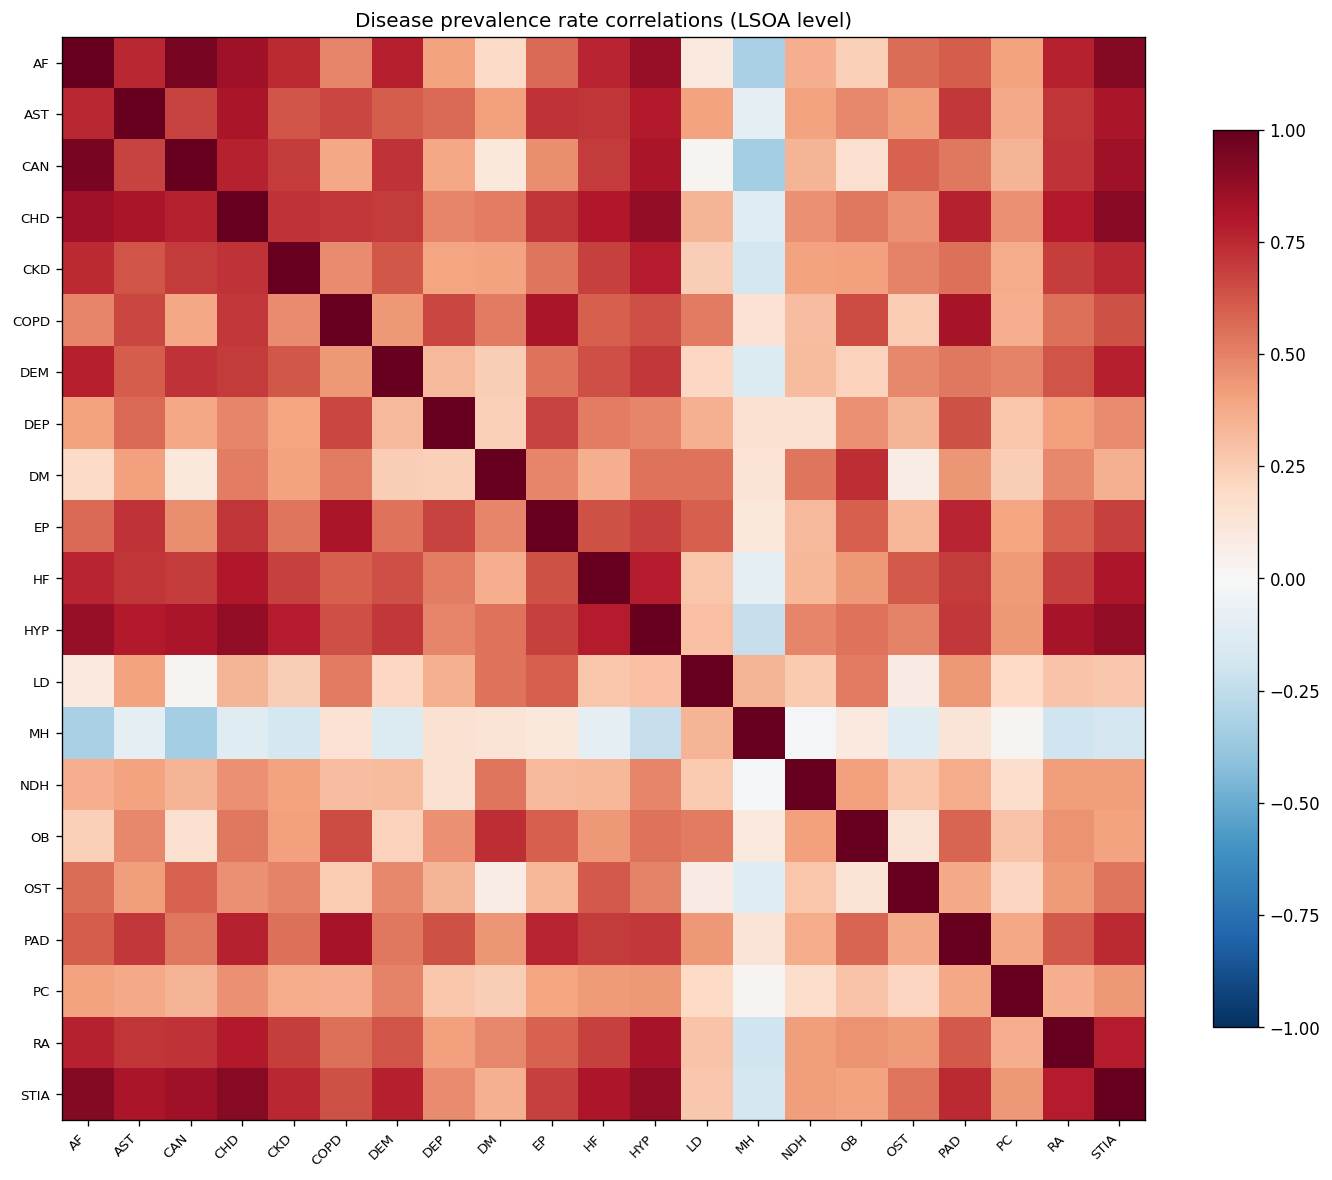

In [6]:
latest = pd.read_csv(sorted(lsoa_dir.glob("health_*.csv"))[-1])
rate_cols = [c for c in latest.columns if c.endswith("_afflicted_rate")]

# Filter to non-zero columns only
valid_cols = [c for c in rate_cols if latest[c].notna().sum() > 1000 and (latest[c] != 0).sum() > 100]
diseases_clean = [c.replace("_afflicted_rate", "") for c in valid_cols]

corr = latest[valid_cols].corr()
corr.columns = diseases_clean
corr.index = diseases_clean

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(diseases_clean)))
ax.set_xticklabels(diseases_clean, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(diseases_clean)))
ax.set_yticklabels(diseases_clean, fontsize=8)
ax.set_title("Disease prevalence rate correlations (LSOA level)")
plt.colorbar(im, shrink=0.8)
fig.tight_layout()
plt.show()

### Expected correlation checks

In [7]:
expected_positive = [
    ("CHD", "HYP", "cardiovascular cluster"),
    ("CHD", "DM", "cardiovascular/metabolic"),
    ("DM", "CKD", "metabolic/renal"),
    ("CHD", "CKD", "cardiovascular/renal"),
    ("DEM", "AF", "age-related"),
]

print("Expected positive correlations:")
for d1, d2, reason in expected_positive:
    col1 = f"{d1}_afflicted_rate"
    col2 = f"{d2}_afflicted_rate"
    if col1 in latest.columns and col2 in latest.columns:
        r = latest[[col1, col2]].dropna().corr().iloc[0, 1]
        status = "OK" if r > 0.3 else "LOW" if r > 0 else "NEGATIVE"
        print(f"  {d1} vs {d2} ({reason}): r = {r:.3f} [{status}]")

Expected positive correlations:
  CHD vs HYP (cardiovascular cluster): r = 0.889 [OK]
  CHD vs DM (cardiovascular/metabolic): r = 0.511 [OK]
  DM vs CKD (metabolic/renal): r = 0.405 [OK]
  CHD vs CKD (cardiovascular/renal): r = 0.726 [OK]
  DEM vs AF (age-related): r = 0.777 [OK]


## 5. Afflicted rate sanity check

After the fix to use ONS population for afflicted counts, the final
`_afflicted_rate` (= `afflicted / pop`) should equal the pipeline's
`_prevalence_rate` for unchanged LSOAs (since `afflicted = prevalence_rate * pop`).
All rates should be ≤ 1.0 for diseases where GP prevalence is ≤ 100%.

In [8]:
pipe_latest = pd.read_csv(sorted(pipeline_dir.glob("health_*.csv"))[-1])
rate_cols_pipe = [c for c in pipe_latest.columns if c.endswith("_prevalence_rate")]

print(f"Pipeline health prevalence rate ranges ({sorted(pipeline_dir.glob('health_*.csv'))[-1].name}):")
for col in rate_cols_pipe:
    vals = pipe_latest[col].dropna()
    if len(vals) == 0 or vals.max() == 0:
        continue
    print(f"  {col.replace('_prevalence_rate', ''):>5}: "
          f"mean={vals.mean():.4f}, max={vals.max():.4f}, "
          f"{'OK' if vals.max() <= 1.0 else f'WARNING max > 1'}")

Pipeline health prevalence rate ranges (health_2024_25.csv):
     AF: mean=0.0235, max=0.0605, OK
    AST: mean=0.0633, max=0.1085, OK
    CAN: mean=0.0396, max=0.0860, OK
    CHD: mean=0.0309, max=0.0747, OK
    CKD: mean=0.0387, max=0.1101, OK
   COPD: mean=0.0197, max=0.0691, OK
    DEM: mean=0.0082, max=0.0558, OK
    DEP: mean=0.1173, max=0.2564, OK
     DM: mean=0.0651, max=0.1444, OK
     EP: mean=0.0066, max=0.0426, OK
     HF: mean=0.0114, max=0.0562, OK
    HYP: mean=0.1569, max=0.3304, OK
     LD: mean=0.0060, max=0.0543, OK
     MH: mean=0.0101, max=0.0908, OK
    NDH: mean=0.0753, max=0.2231, OK
     OB: mean=0.1131, max=0.2267, OK
    OST: mean=0.0046, max=0.0354, OK
    PAD: mean=0.0058, max=0.0410, OK
     PC: mean=0.0058, max=0.0625, OK
     RA: mean=0.0067, max=0.0193, OK
   STIA: mean=0.0197, max=0.0483, OK


## Interpretation

**Key things to verify:**
- England-level rates from aggregation should exactly match LSOA rollup
  (any discrepancy indicates a bug)
- Prevalence distributions should be unimodal and roughly normal
  (bimodality suggests systematic GP-LSOA matching issues)
- Cardiovascular diseases should cluster together (CHD, HYP, DM, CKD)
- Prevalence rates should generally be ≤ 1.0; values above 1 indicate
  a GP practice reporting more disease registrations than its list size
- Diseases that appear only in later QOF years (CVDPP, SMOK, THY)
  will have NaN/zero for early years — this is expected